# Phase 3 – File 2: Gradient Descent – The Learning Engine

**From a mathematical compass to a working optimizer.**

---

## 1. The big picture

We have a **loss surface** $L(\mathbf{w})$.  
The **gradient** $\nabla L$ tells us the **direction of steepest ascent**.  
To *reduce* loss we walk in the **opposite** direction:

$$ \mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} - \alpha \, \nabla L(\mathbf{w}_{\text{old}}) $$

- $\alpha$ = **learning rate** (step size).
- The minus sign flips the arrow **downhill**.

---

## 2. The “hiker in the fog” analogy (expanded)

1. **Start** at a random location on the mountain (randomly initialise weights).
2. **Feel the slope** at your feet → compute $\nabla L$.
3. **Take a step** of length $\alpha$ in the *downhill* direction $-\nabla L$.
4. **Repeat** until the slope is (almost) zero – you have reached a valley.

---

## 3. Learning‑rate sweet spot

| $\alpha$ | Behaviour | What you see in practice |
|----------|-----------|--------------------------|
| **Too small** (e.g. $10^{-6}$) | Baby steps → *extremely* slow convergence | Training for days without improvement |
| **Too large** (e.g. $2.0$) | Giant leaps → overshoot, loss *increases* | Loss explodes to `inf` |
| **Just right** (e.g. $0.01$–$0.1$) | Steady, confident strides | Loss drops quickly and smoothly |

---

## 4. Batch vs. Stochastic vs. Mini‑batch

- **Full‑batch GD** – compute $\nabla L$ over the *entire* dataset → accurate but **prohibitively slow** for millions of images.
- **Stochastic GD (SGD)** – use **one random example** → very noisy, but **fast**.
- **Mini‑batch GD** – use **32–256 examples** → good balance of speed & stability. **This is what you see in 99 % of code**.

---

## 5. Full‑featured code – watch every step

We minimise $L(w) = (w-3)^2 + 1$.  The true minimum is $w=3$, $L=1$.

Iter |        w |     grad |     loss
--------------------------------------
   0 |  -5.0000 | -16.0000 |  65.0000
   1 |  -3.4000 | -12.8000 |  41.9600
   2 |  -2.1200 | -10.2400 |  27.2144
   3 |  -1.0960 |  -8.1920 |  17.7772
   4 |  -0.2768 |  -6.5536 |  11.7374
   5 |   0.3786 |  -5.2429 |   7.8719
  46 |   2.9997 |  -0.0006 |   1.0000
  47 |   2.9998 |  -0.0004 |   1.0000
  48 |   2.9998 |  -0.0004 |   1.0000
  49 |   2.9999 |  -0.0003 |   1.0000
  50 |   2.9999 |  -0.0002 |   1.0000


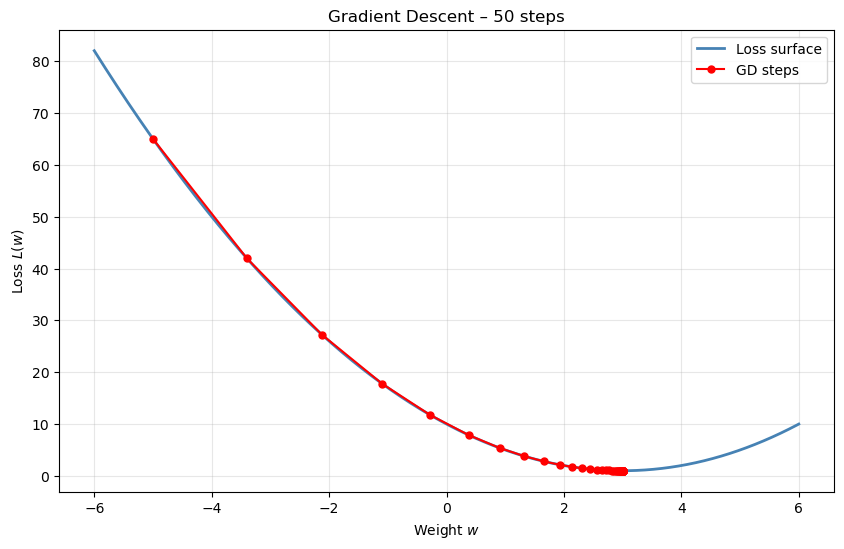

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Loss and analytic gradient -----
def loss(w): return (w - 3)**2 + 1
def grad(w): return 2*(w - 3)

# ----- GD loop with verbose printing -----
w = -5.0                # random start
alpha = 0.1             # learning rate
history = [w]

print(f"{'Iter':>4} | {'w':>8} | {'grad':>8} | {'loss':>8}")
print('-'*38)
for i in range(51):
    g = grad(w)
    w_new = w - alpha * g
    history.append(w_new)
    if i < 6 or i > 45:
        print(f"{i:4d} | {w:8.4f} | {g:8.4f} | {loss(w):8.4f}")
    w = w_new

# ----- Plot the path -----
w_grid = np.linspace(-6, 6, 500)
plt.figure(figsize=(10,6))
plt.plot(w_grid, loss(w_grid), 'steelblue', lw=2, label='Loss surface')
plt.plot(history, [loss(wi) for wi in history], 'ro-', markersize=5, label='GD steps')
plt.title('Gradient Descent – 50 steps')
plt.xlabel('Weight $w$')
plt.ylabel('Loss $L(w)$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Mini‑batch example with NumPy (SGD‑style)

We simulate a tiny dataset where the true model is $y = 2x + 1$.

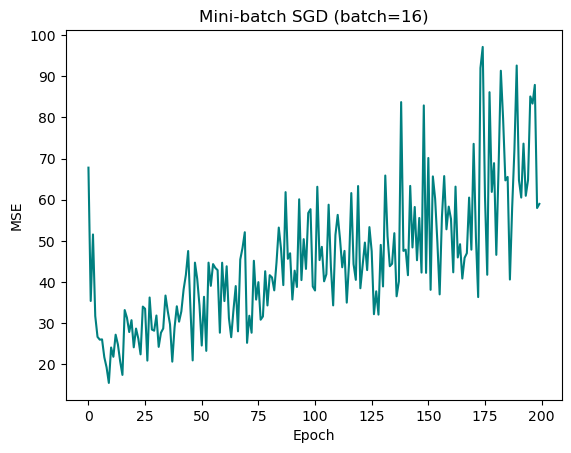

Final w ≈ 5.319, b ≈ -5.345  (true 2.0, 1.0)


In [ ]:
np.random.seed(0)
X = np.random.rand(100, 1) * 5          # 100 points in [0,5]
y = 2 * X + 1 + np.random.randn(100,1)*0.5   # noisy linear

# parameters
w = np.random.randn(1)
b = np.random.randn(1)
lr = 0.01
batch_size = 16

losses = []
for epoch in range(200):
    idx = np.random.choice(len(X), batch_size, replace=False)
    Xb, yb = X[idx], y[idx]
    
    # forward
    y_pred = Xb @ w + b
    err = y_pred - yb
    L = np.mean(err**2)
    losses.append(L)
    
    # backward (analytic)
    dL_dw = 2 * np.mean(Xb * err)
    dL_db = 2 * np.mean(err)
    
    # update
    w -= lr * dL_dw
    b -= lr * dL_db

plt.plot(losses, 'teal')
plt.title('Mini‑batch SGD (batch=16)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.show()
print(f'Final w ≈ {w.item():.3f}, b ≈ {b.item():.3f}  (true 2.0, 1.0)')

## 7. TL;DR

- **Gradient Descent** = repeated step $-\alpha \nabla L$.
- **Learning rate** is the single most important hyper‑parameter.
- **Mini‑batch** gives the best speed‑vs‑stability trade‑off.

---

**Next file:** *Backpropagation* – how the gradient is computed inside a deep net.